Notebook for generating the demonstratory plots in the README.

In [ ]:
from quantumthreattracker.lifespan_estimator import HardwareRoadmap

hardware_roadmap = HardwareRoadmap()

# Baseline hardware assumed to be available in 2025.
baseline_qubit_count = 1000
baseline_error_rate = 1e-3
baseline_measurement_time = 100  # ns
baseline_gate_time = 50  # ns

# The following are all percentages used for building the hardware roadmap.
yearly_qubit_count_increase = 75
yearly_error_rate_decrease = 20
yearly_measurement_time_decrease = 10
yearly_gate_time_decrease = 10

for i in range(20):
    max_qubits = int(baseline_qubit_count * ((1 + yearly_qubit_count_increase / 100)**i))
    error_rate = baseline_error_rate * ((1 - yearly_error_rate_decrease / 100)**i)
    measurement_time = str(baseline_measurement_time * (1 - yearly_measurement_time_decrease / 100)**i) + " ns"
    gate_time = str(baseline_gate_time * (1 - yearly_gate_time_decrease / 100)**i) + " ns"
    params = {
        "qubitParams": {
            "name": "Custom",
            "instructionSet": "GateBased",
            "oneQubitMeasurementTime": measurement_time,
            "oneQubitGateTime": gate_time,
            "twoQubitGateTime": gate_time,
            "tGateTime": gate_time,
            "oneQubitMeasurementErrorRate": error_rate,
            "oneQubitGateErrorRate": error_rate,
            "twoQubitGateErrorRate": error_rate,
            "tGateErrorRate": error_rate,
        },
        "constraints": {
            "maxPhysicalQubits": max_qubits
        }
    }
    hardware_roadmap.add(timestamp=1735689600 + 31536000 * i, estimator_params=params)

In [2]:
from quantumthreattracker.lifespan_estimator import LifespanEstimator

lifespan_estimator = LifespanEstimator(hardware_roadmap)

In [3]:
protocols = [
    {"algorithm": "RSA", "keySize": 1024},
    {"algorithm": "RSA", "keySize": 2048},
    {"algorithm": "RSA", "keySize": 4096},
    {"algorithm": "RSA", "keySize": 8192},
    {"algorithm": "DH-SP", "keySize": 2048},
    {"algorithm": "DH-SP", "keySize": 4096},
    {"algorithm": "DH-SP", "keySize": 8192},
    {"algorithm": "ECDH", "keySize": 256},
    {"algorithm": "ECDH", "keySize": 384},
    {"algorithm": "ECDH", "keySize": 512},
    ]

In [4]:
lifespan_estimator.generate_report(protocols=protocols, print_progress=True)

Estimating threats for RSA-1024
Estimating threats for RSA-2048
Estimating threats for RSA-4096
Estimating threats for RSA-8192
Estimating threats for DH-SP-2048
Estimating threats for DH-SP-4096
Estimating threats for DH-SP-8192
Estimating threats for ECDH-256
Estimating threats for ECDH-384
Estimating threats for ECDH-512


In [5]:
lifespan_estimator.get_report(detail_level=1, soonest_threat_only=True)

[{'protocol': 'RSA-1024',
  'threats': [{'timestamp': 2082585600, 'runtime': 4573800000000}]},
 {'protocol': 'RSA-2048',
  'threats': [{'timestamp': 2114121600, 'runtime': 24024000000000}]},
 {'protocol': 'RSA-4096',
  'threats': [{'timestamp': 2177193600, 'runtime': 118800000000000}]},
 {'protocol': 'RSA-8192',
  'threats': [{'timestamp': 2208729600, 'runtime': 863460000000000}]},
 {'protocol': 'DH-SP-2048',
  'threats': [{'timestamp': 2208729600, 'runtime': 3871252611072}]},
 {'protocol': 'DH-SP-4096',
  'threats': [{'timestamp': 2240265600, 'runtime': 10272821370636}]},
 {'protocol': 'DH-SP-8192',
  'threats': [{'timestamp': 2271801600, 'runtime': 175545601228800}]},
 {'protocol': 'ECDH-256',
  'threats': [{'timestamp': 2145657600, 'runtime': 12436267477920}]},
 {'protocol': 'ECDH-384',
  'threats': [{'timestamp': 2177193600, 'runtime': 10834183968300}]},
 {'protocol': 'ECDH-512',
  'threats': [{'timestamp': 2208729600, 'runtime': 25594294419892}]}]

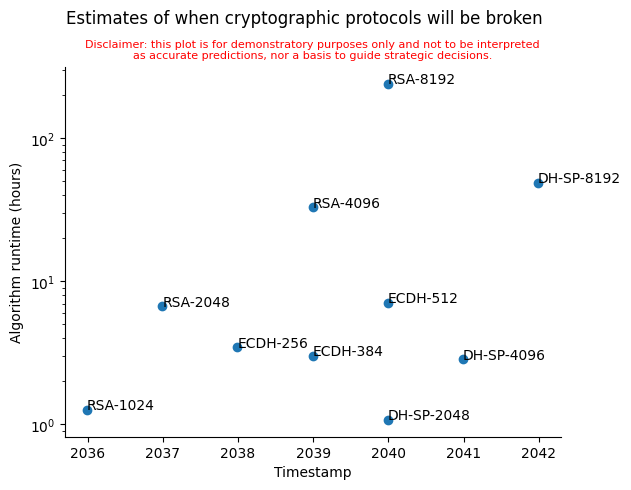

In [6]:
import matplotlib.pyplot as plt

fig = plt.subplots()[0]
ax = lifespan_estimator.plot_threats()
fig.suptitle('Estimates of when cryptographic protocols will be broken', y=1)
ax.set_title('Disclaimer: this plot is for demonstratory purposes only and not to be interpreted\nas ' +
             'accurate predictions, nor a basis to guide strategic decisions.', color='red', size=8)
plt.show()

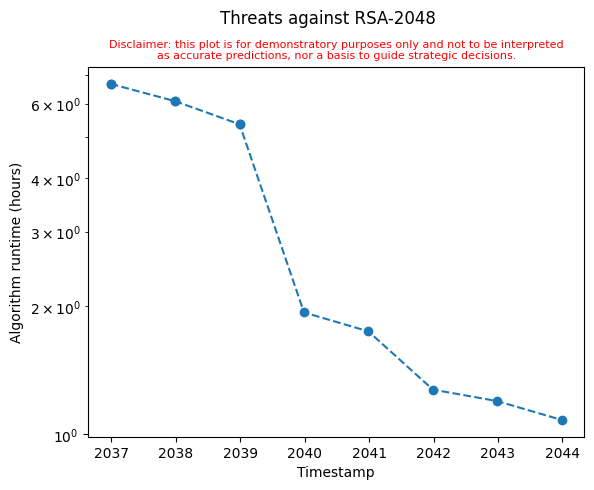

In [7]:
fig = plt.subplots()[0]
ax = lifespan_estimator.plot_threats(protocol="RSA-2048")
fig.suptitle('Threats against RSA-2048', y=1)
ax.set_title('Disclaimer: this plot is for demonstratory purposes only and not to be interpreted\nas ' +
             'accurate predictions, nor a basis to guide strategic decisions.', color='red', size=8)
plt.show()